# NCAA forecasting | ML engineering case study
**Alvaro Mendizabal · achieved 2026 release and ongoing private research**

This notebook presents approved aggregate evidence. It does not contain or invoke the training system, model parameters, private data or submission code. All displayed outputs are saved for review without cloud access.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / 'portfolio').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'portfolio'))
from current_research import load, chart
import pandas as pd
from IPython.display import display
e = load()
s = e['scored']
w = e['women']
display(pd.DataFrame([{'Evidence': 'Scored late release', 'Brier': s['incumbent'], 'Setting': s['setting']}, {'Evidence': 'Women research candidate', 'Brier': w['margin'], 'Setting': w['setting']}]))

,Evidence,Brier,Setting
0,Scored late release,0.109490,"Late post-competition score, not an original c..."
1,Women research candidate,0.128306,"189 main-bracket games, 2023–2025; reused hist..."


## 1. An achieved score, not an inferred one
Submission **56447505** is recorded COMPLETE at **0.1094899 Brier**, compared with the published winning benchmark of **0.1097454**. The numerical difference is **0.0002555**, approximately **0.23% lower Brier**. This post-competition result is not an original first-place finish or evidence of a guaranteed future advantage. Brier measures squared probability error; historical and Kaggle populations remain separate.

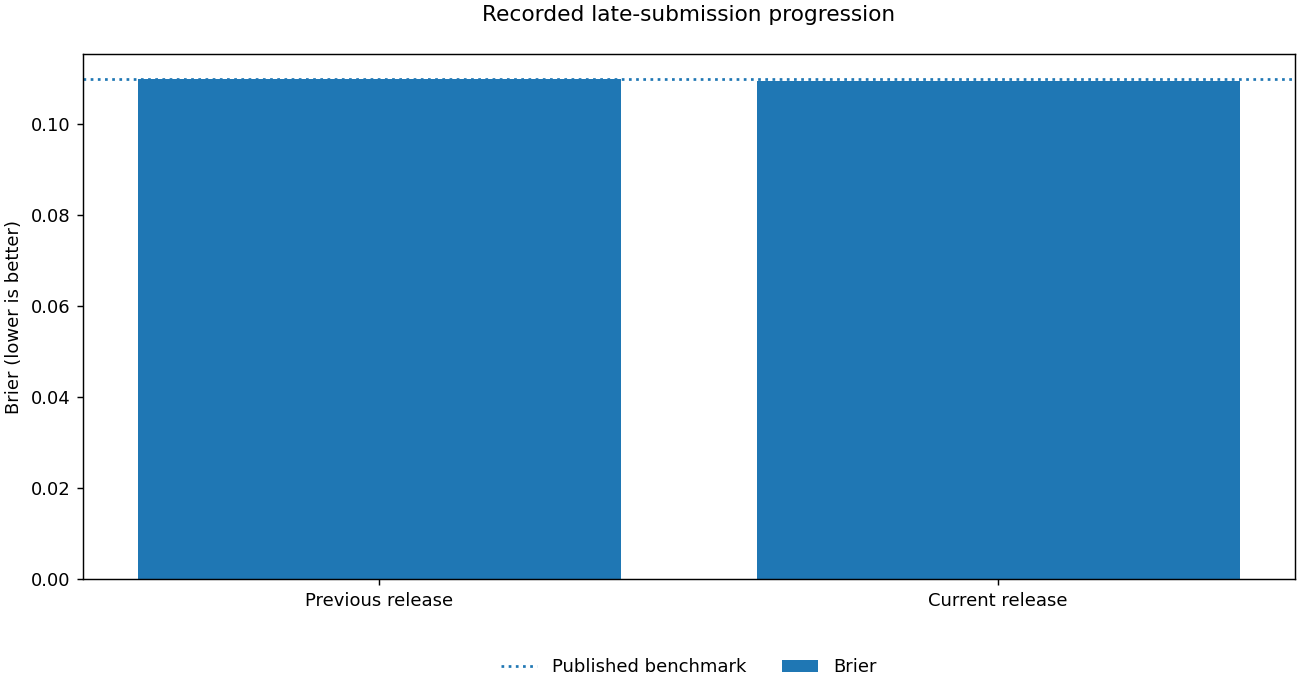

Improvement over predecessor: 0.0003792
Below published benchmark: 0.0002555


In [2]:
chart('scored', 'Recorded late-submission progression', ['Previous release', 'Current release'], {'Brier': [s['predecessor'], s['incumbent']]}, 'Brier (lower is better)', s['published_benchmark'])
print('Improvement over predecessor:', round(s['predecessor']-s['incumbent'], 7))
print('Below published benchmark:', round(s['published_benchmark']-s['incumbent'], 7))

## 2. Research judgment before additional complexity
Full feature expansion, residual dimensionality reduction, chronological subset selection and error corrections did not automatically improve the compact reference. Those rejected directions are retained in earlier evidence. A controlled change to learning score margins produced useful complementary forecasts and then an improved scored men's release. The next question was whether that mechanism transfers to women.

The earlier women's screen improved six of eight historical years. It justified a fuller ensemble check, not an immediate submission.

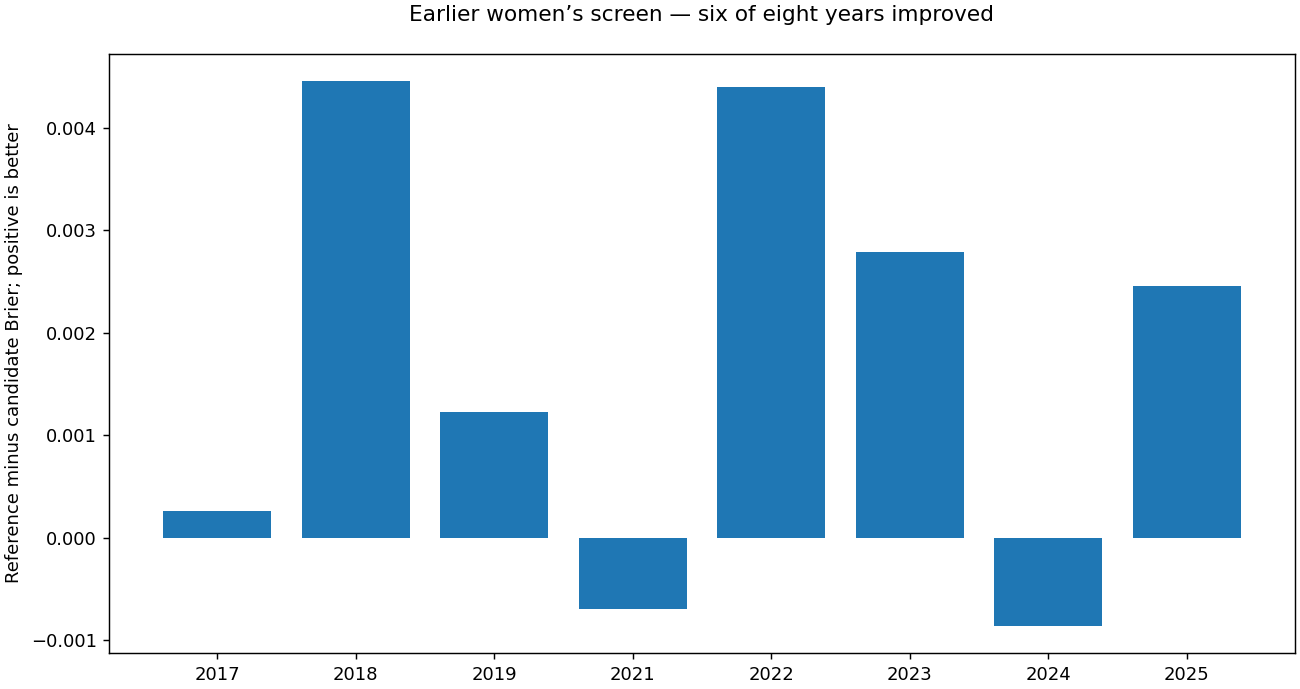

In [3]:
chart('women_screen_history', 'Earlier women’s screen — six of eight years improved', e['screen']['years'], {'Brier reduction': e['screen']['gain']}, 'Reference minus candidate Brier; positive is better')

## 3. Does the women's candidate survive fuller training?
The same historical 2023–2025 games compare a frozen reference, a matched win/loss control, and the margin-based ensemble. Whole-season inner omissions and three fixed random repeats assess training stability. Every outer assessment year is excluded from fitting, early stopping and calibration. The scored men's probabilities remain untouched; this experiment makes no Kaggle submission.

,Core,Binary control,Margin candidate,Gain over core,Gain over binary
0,0.129214,0.128993,0.128306,0.000908,0.000687


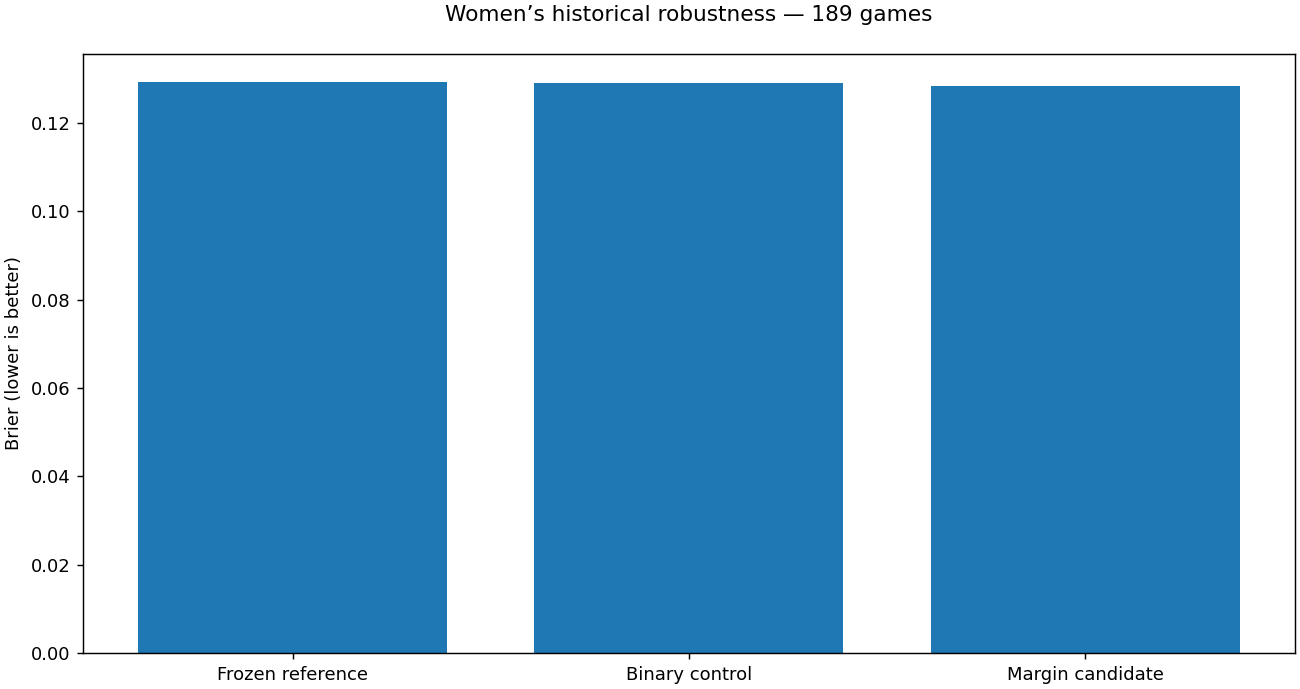

In [4]:
display(pd.DataFrame([{'Core': w['core'], 'Binary control': w['binary'], 'Margin candidate': w['margin'], 'Gain over core': w['core']-w['margin'], 'Gain over binary': w['binary']-w['margin']}]))
chart('women_robustness', 'Women’s historical robustness — 189 games', ['Frozen reference', 'Binary control', 'Margin candidate'], {'Brier': [w['core'],w['binary'],w['margin']]}, 'Brier (lower is better)')

,year,games,core,margin,binary
0,2023,63,0.179331,0.177769,0.180774
1,2024,63,0.115484,0.114968,0.115215
2,2025,63,0.092826,0.092182,0.090990


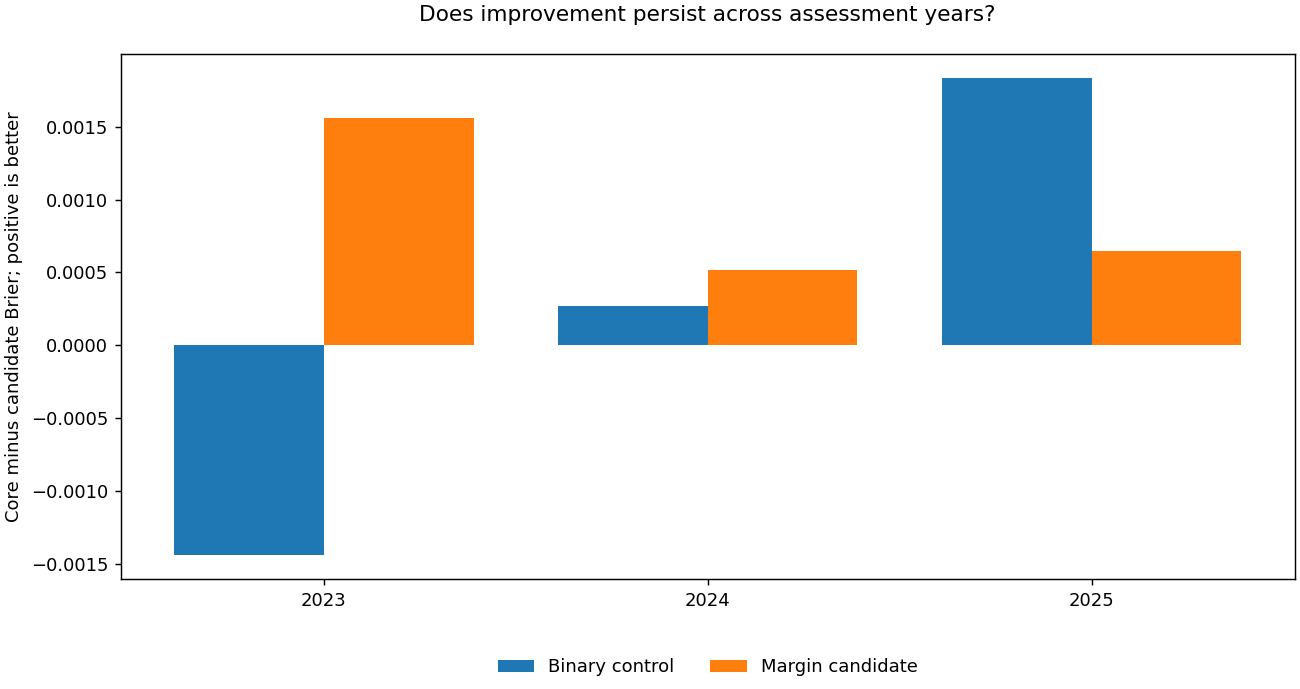

In [5]:
years = pd.DataFrame(w['years'])
display(years)
chart('women_robustness_years', 'Does improvement persist across assessment years?', years.year.tolist(), {'Binary control': (years.core-years.binary).tolist(), 'Margin candidate': (years.core-years.margin).tolist()}, 'Core minus candidate Brier; positive is better')

The margin candidate improves the reference in all three years. That does not imply it always beats the matched binary control: the binary control is better in 2025. The pooled target advantage is **0.0006872**, while the overall gain against the core is **0.0009077**. Both comparisons matter.

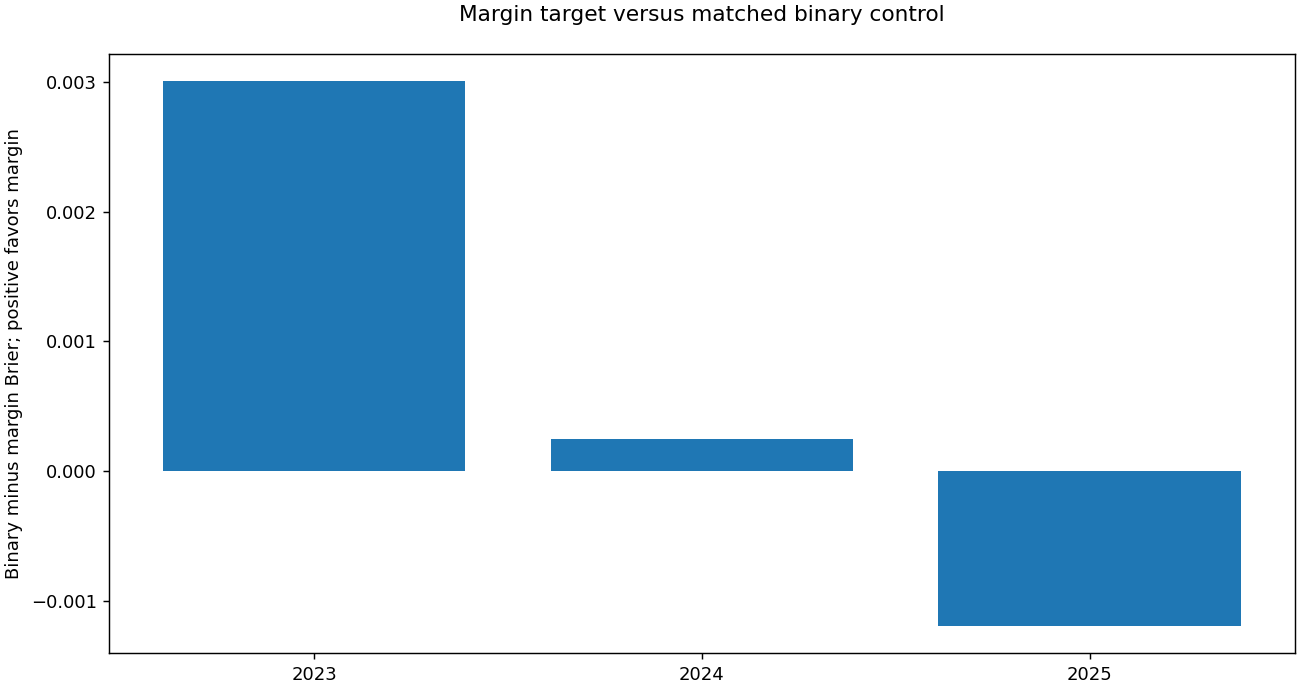

In [6]:
chart('women_objective_ablation', 'Margin target versus matched binary control', years.year.tolist(), {'Margin advantage': (years.binary-years.margin).tolist()}, 'Binary minus margin Brier; positive favors margin')

,repeat,brier,gain
0,Repeat 1,0.128380,0.000834
1,Repeat 2,0.128282,0.000932
2,Repeat 3,0.128259,0.000954


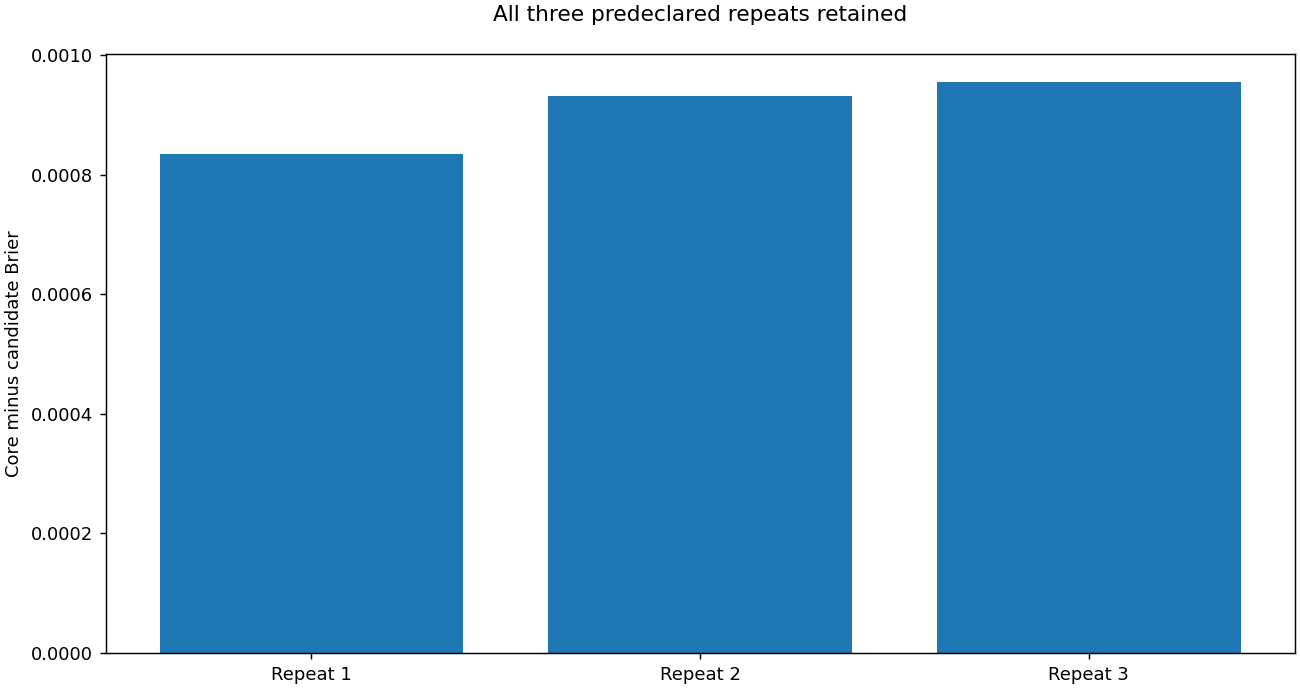

In [7]:
repeat = pd.DataFrame(w['repeats'])
repeat['gain'] = w['core']-repeat.brier
display(repeat)
chart('women_robustness_repeats', 'All three predeclared repeats retained', repeat['repeat'].tolist(), {'Brier reduction': repeat.gain.tolist()}, 'Core minus candidate Brier')

## 4. Decision and uncertainty
All seven predeclared robustness criteria passed. The completed run performed **234 model fits**, passed **78 regression tests**, and took **53.43 seconds overall**. Its decision is **CANDIDATE_BUILD_REVIEW**, not a new scored release.

These development years have been reused, and the proposal was selected following earlier experiments. Inner held-out predictions guide both early stopping and calibration. Three random repeats do not create three independent tournaments. Conditional uncertainty summaries do not correct for the entire adaptive research history. No 2027 improvement can be inferred from the observed late score.

In [8]:
display(pd.DataFrame([{'Gate': k, 'Passed': v} for k,v in w['checks'].items()]))
print('Women decision:', w['decision'])
print('Women Kaggle score:', w['kaggle_score'])
print('Model fits performed by this report:', 0)

,Gate,Passed
0,all_tournament_guard,True
1,at_least_two_seasons,True
2,conditional_support,True
3,every_predeclared_seed_nonnegative,True
4,gain_over_strong_core,True
5,margin_beats_matched_binary,True
6,worst_season_guard,True


Women decision: CANDIDATE_BUILD_REVIEW
Women Kaggle score: None
Model fits performed by this report: 0


## 5. Engineering, ownership and the 2027 boundary
The private pipeline preserves source/data/checkpoint identities, protects previously scored predictions, validates schema and probabilities, reuses completed work, and packages failures for diagnosis. The public report exposes outcomes and professional reasoning—not the evolving training implementation or detailed future recipe.

Existing public source and licenses remain accessible; this publication does not erase history or retract earlier grants. Going forward, detailed implementation stays in the owner's workspace. Attribution to the compact reference's public author is retained.

For 2027, preserve the current baseline, audit season-specific assumptions, record timestamped pregame snapshots and forecasts, and freeze evaluation and selection rules before future outcomes arrive. The next competition's actual rules must be reviewed when available; no schedule or external-data permission is assumed. See the employer walkthrough and 2027 readiness note for the high-level plan.

In [9]:
print('REPORT_COMPLETE — approved aggregates; no training or submission')

REPORT_COMPLETE — approved aggregates; no training or submission
